In [17]:
import os
from pathlib import Path 
import matplotlib.pyplot as plt
path=Path.cwd().parent
print(os.listdir('./'))

['Object_detection.ipynb']


In [18]:
import torch
torch.cuda.is_available()

True

In [19]:
Path('ROD-Dataset/data.yaml')

PosixPath('ROD-Dataset/data.yaml')

In [20]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

In [25]:
img_dir=path/'ROD-Dataset/train/images'

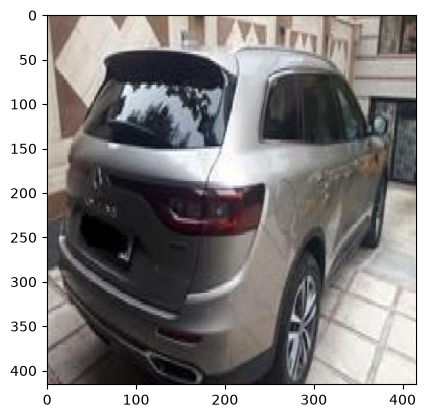

In [34]:
for d in os.listdir(img_dir):
    img=cv2.imread(os.path.join(img_dir,d))
    img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.show() 
    break

In [ ]:
model=YOLO('yolov8m.pt') 

In [ ]:
result=model.train(
    data=path/'ROD-Dataset/data.yaml',
    epochs=15 ,
    imgsz=640,
    device='cuda',
    workers=8,
)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=ROD-Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display


In [6]:
os.listdir()

['Object_detection.ipynb']

In [12]:
model=YOLO(path/'runs/detect/train-2/weights/best.pt')


In [15]:
metrics = model.val(
    data=path/'ROD-Dataset/data.yaml',
    split='val',             
    device='cuda',
    imgsz=640
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7806MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 204.1±42.6 MB/s, size: 29.3 KB)
val: Scanning /home/vaibhav/Desktop/CNN/Obstacle detection/ROD-Dataset/valid/labels.cache... 3511 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3511/3511 818.1Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 821, len(boxes) = 5572. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 3.4it/s 1:050.3sss
                   all       3511       5572      0.867        0.9      0.924       0.76
                  Bike         88         95      0.958      0.961      0.975      0.883
              Building         95        101   

In [17]:
metrics.box.map50 # mAP50

np.float64(0.9239901928606662)

In [21]:
metrics.box.map # mAP50-95

np.float64(0.7600522266785004)

In [ ]:
test_metrics=model.val(
    data=path/'ROD-Dataset/data.yaml',
    split='test',
    device='cuda',
    imgsz=640
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7806MiB)
Model summary (fused): 93 layers, 25,854,235 parameters, 0 gradients, 78.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 194.4±61.8 MB/s, size: 52.5 KB)
val: Scanning /home/vaibhav/Desktop/CNN/Obstacle detection/ROD-Dataset/test/labels... 1629 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1629/1629 4.3Kit/s 0.4s0.1s
val: New cache created: /home/vaibhav/Desktop/CNN/Obstacle detection/ROD-Dataset/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 416, len(boxes) = 2372. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 102/102 3.2it/s 31.4s0.3s
                   all       1629       2372      0

In [34]:
test_metrics.box.map50

np.float64(0.920098415714664)

In [35]:
test_metrics.box.map

np.float64(0.7690149331227853)